# Automated Customer Complaint Analyzer (LLM-Based)

### Task 1 - Set up the project environment

In [2]:
# - openai: used to connect to OpenAI's API (we will use it later to fine-tune and run the model)
# - python-dotenv: helps us safely load our API key from a .env file instead of writing it directly in code
!pip install openai python-dotenv

In [3]:
!pip install --upgrade openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.6 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.31.0
    Uninstalling openai-2.31.0:
      Successfully uninstalled openai-2.31.0


Importing modules

In [4]:
# Import required libraries for the project

import pandas as pd          # Used to load and work with the dataset (customer complaints in table format)

import os, time             # os: helps access environment variables (like API keys)
                            # time: used for adding delays or tracking execution time if needed

from openai import OpenAI   # Main library to interact with OpenAI API (for fine-tuning and model usage)

from dotenv import load_dotenv  # Loads API keys from a .env file into the environment (secure way to manage secrets)

import json                 # Used to read/write data in JSON format (required for training data and API responses)

import matplotlib.pyplot as plt  # Used for visualizing results (e.g., model performance, score distribution)

print("Modules are imported.")

Modules are imported.


Setting up the OpenAI API:

* Prepare a .env file to store the OpenAI API key.
* Uploading the .env file to our colab environment
* Load the API key and setup the API

In [5]:
load_dotenv('apikey.env.txt')
APIKEY = os.getenv('MY_API_KEY')

Creating OpenAI Client

In [6]:
# Step: Create OpenAI client
# The "client" is an object that connects our code to OpenAI's API.
# We pass our API key so OpenAI knows who is making the request.

# What is happening here:
# - OpenAI() creates a client instance (like setting up a connection)
# - This client will be used later to:
#     • send training data for fine-tuning
#     • generate responses from the model
#     • interact with OpenAI services
# Client is called API handler
client = OpenAI(
  api_key = APIKEY
)
client

### Task 2 - Prepare the training data

Loading the provided `Customer Complaints.csv`



In [7]:
"""
Each row contains:
  Complaints → raw text (input)
  Details → structured output (target / correct extracted information)
"""
training_data = pd.read_csv('Customer Complaints.csv')
training_data #This dataset is labeled

,Complaints,Details
0,Unreliable internet! Sick of constant outages...,"{""Topic"": ""Internet"", ""Problem"": ""Unreliable s..."
1,TV signal keeps dropping during crucial momen...,"{""Topic"": ""TV"", ""Problem"": ""Signal dropout"", ""..."
2,Phone line always crackling! Can't hear a thi...,"{""Topic"": ""Phone"", ""Problem"": ""Crackling line""..."
3,Ridiculous prices for such terrible service! ...,"{""Topic"": ""Billing"", ""Problem"": ""Overcharged"",..."
4,Internet speed slower than a snail! Can't str...,"{""Topic"": ""Internet"", ""Problem"": ""Slow speed"",..."
...,...,...
62,Poor call quality during international calls! ...,"{""Topic"": ""Phone"", ""Problem"": ""Poor call quali..."
63,Incorrect charges on my bill every month! Unre...,"{""Topic"": ""Billing"", ""Problem"": ""Incorrect cha..."
64,This service is terrible! Can't believe I'm pa...,"{""Topic"": ""PulseNet General"", ""Problem"": ""Gene..."
65,This product is a complete waste of money! Dis...,"{""Topic"": ""PulseNet General"", ""Problem"": ""Gene..."


OpenAI fine-tuning does NOT accept CSV directly.
It expects data in a chat format (JSONL) like.
Because GPT models are trained as chat systems, not simple input-output models. Each role has a purpose:

system → tells the model what task to do
user → provides the input (complaint)
assistant → provides the correct answer (expected output)

**Converting the Complaints records to json**

To be able to use the data for the fine-tuning purpose, we first need to convert each row of the dataframe into the following format:

<pre>
<code>
{
  <span style="color: blue;">"messages"</span>: [
    {
      <span style="color: blue;">"role"</span>: <span style="color: red;">"system"</span>,
      <span style="color: blue;">"content"</span>: "<span style="color: green;">Providing context about the user's prompt.
                  It may include information about the task,
                  instructions, or background details relevant
                  to the conversation.</span>"
    },
    {
      <span style="color: blue;">"role"</span>: <span style="color: red;">"user"</span>,
      <span style="color: blue;">"content"</span>: "<span style="color: green;">the prompt or input provided by the user,
                  which typically initiates the conversation with the assistant.</span>"
    },
    {
      <span style="color: blue;">"role"</span>: <span style="color: red;">"assistant"</span>,
      <span style="color: blue;">"content"</span>: "<span style="color: green;">The desired response or output generated by
                  the assistant in response to the user's prompt.</span>"
    }
  ]
}
</code>
</pre>

Let's get started!

Let's define a method that get's a row of the dataframe and convert it into the json format

In [8]:
def save_as_json(row): # This function converts one row → one training example

  system_content = """
      Given a customer complaint text, extract and return the following information in json (dict) format:
      - Topic: The product/department that the customer has a complaint about.
      - Problem: A two or three-word description of what exactly the problem is.
      - Customer_Dissatisfaction_Index: is a number between 0 and 100 showing
             how angry the customer is about the problem.
  """
  # one trining sample
  formatted_data = {
        "messages": [
            {"role": "system", "content": system_content}, # training instructions
            {"role": "user", "content": row.Complaints},  # training complaint text
            {"role": "assistant", "content": row.Details} # training correct structured answer
        ]
      }

  with open("training_data.json", "a") as json_file:
        json.dump(formatted_data, json_file)
        json_file.write("\n")

Now let's use of this method to generate the `training_data.json`

In [9]:
for idx, row in training_data.iterrows():
  save_as_json(row)

### Task 3 - Fine-tune GPT 3.5 based on our training data

Let's import the json file we prepared as our training data

Before fine-tuning, OpenAI needs your dataset:

Uploaded,
Validated,
Stored internally.

In [11]:
# 🔷 client.files.create(...) — Notes

# Purpose:
# Upload a file to OpenAI so it can be used later (e.g., for fine-tuning)

# What it does:
# - Takes a local file
# - Sends it to OpenAI servers via API
# - Stores and validates the file

# Input:
# - file → opened in binary mode (e.g., open('file.json', 'rb'))
# - purpose → tells how the file will be used ('fine-tune')

# Output:
# - Returns a FileObject with:
#     • id (used later for training)
#     • status ('uploaded' / 'processed')

# Key point:
# This step only uploads the data — it does NOT start training

data_file = client.files.create(
    file = open('training_data.json', 'rb'),
    purpose = 'fine-tune'
)
data_file

FileObject(id='file-U57hzRb9Pn9MMzFUBaeZGg', bytes=46722, created_at=1777143824, filename='training_data.json', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

Create the Fine Tuning Job

In [15]:
# This step starts the fine-tuning job on OpenAI servers
# The model is not ready yet — it is currently being trained

# status='validating_files' means:
# OpenAI is checking if the dataset format is correct

# After this, training will begin automatically

# We can use the job ID to track progress

fine_tuning_job = client.fine_tuning.jobs.create(
    training_file=data_file.id,
    model='gpt-3.5-turbo',
    hyperparameters={
        'n_epochs': 1
    }
)

fine_tuning_job

FineTuningJob(id='ftjob-rKFojGvyOkowCd6Bfjme4BUP', created_at=1777145844, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-3.5-turbo-0125', object='fine_tuning.job', organization_id='org-dFkzsISWLAQmZ2JhV9QokbP7', result_files=[], seed=179368704, status='validating_files', trained_tokens=None, training_file='file-U57hzRb9Pn9MMzFUBaeZGg', validation_file=None, estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1))), user_provided_suffix=None, usage_metrics=None, shared_with_openai=False, eval_id=None, internal_worker_backend=None, internal_peashooter_execution=None, train_experiment_id=None, eval_experiment_id=None)

Let's retrieve the state of the fine-tune

In [22]:
# Check the current status of the fine-tuning job
# This helps us know whether training is still running or completed

# retrieve() gets the latest job info using the job ID
# status tells us the current stage (validating, running, succeeded, etc.)

retrieved_job = client.fine_tuning.jobs.retrieve(fine_tuning_job.id)
status = retrieved_job.status
print(status)

succeeded


### Task 4 - Evaluate model

Let's retrieve the event messages to check out the learning process of our fine-tuning job.

In [24]:
events = list(client.fine_tuning.jobs.list_events(fine_tuning_job_id=retrieved_job.id, limit=100).data)
events

[FineTuningJobEvent(id='ftevent-PjUqniy1l9DB67pYjMylbe3J', created_at=1777147047, level='info', message='The job has successfully completed', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-fwUVcJixi5eiddiuD0lz8jGE', created_at=1777147045, level='info', message='Usage policy evaluations completed, model is now enabled for sampling', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-gJgmigGYExxXk0pd5o1Dd72f', created_at=1777147045, level='info', message='Moderation checks for snapshot ft:gpt-3.5-turbo-0125:personal::DYdEEz3x passed.', object='fine_tuning.job.event', data={'blocked': False, 'results': [{'flagged': False, 'category': 'harassment/threatening', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'sexual', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'sexual/minors', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'propaganda', 'enforcement': 'blocking'}, {'flagg

In [25]:
for e in events:
  print(e.message)

The job has successfully completed
Usage policy evaluations completed, model is now enabled for sampling
Moderation checks for snapshot ft:gpt-3.5-turbo-0125:personal::DYdEEz3x passed.
Evaluating model against our usage policies
New fine-tuned model created
Step 67/67: training loss=0.06
Step 66/67: training loss=0.17
Step 65/67: training loss=0.33
Step 64/67: training loss=0.09
Step 63/67: training loss=0.26
Step 62/67: training loss=0.57
Step 61/67: training loss=0.15
Step 60/67: training loss=0.08
Step 59/67: training loss=0.40
Step 58/67: training loss=0.16
Step 57/67: training loss=0.03
Step 56/67: training loss=0.08
Step 55/67: training loss=0.10
Step 54/67: training loss=0.04
Step 53/67: training loss=0.09
Step 52/67: training loss=0.11
Step 51/67: training loss=0.29
Step 50/67: training loss=0.16
Step 49/67: training loss=0.19
Step 48/67: training loss=0.50
Step 47/67: training loss=0.10
Step 46/67: training loss=0.13
Step 45/67: training loss=0.05
Step 44/67: training loss=0.0

In [27]:
for e in events:
  print(e.data)

{}
{}
{'blocked': False, 'results': [{'flagged': False, 'category': 'harassment/threatening', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'sexual', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'sexual/minors', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'propaganda', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'hate', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'hate/threatening', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'illicit', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'violence', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'advice', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'self-harm/intent', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'self-harm/instructions', 'enforcement': 'non_blocking'}, {'flagged': False, 'category': 'sensitive', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'highly-sensitive', 'enforcement'

Let's extract the training loss in each learning step

In [31]:
steps = []
train_loss = []

for e in events:
    if e.data:
        step = e.data.get('step')
        loss = e.data.get('train_loss')

        if step is not None and loss is not None:
            steps.append(step)
            train_loss.append(loss)

print(steps)
print(train_loss)

[67, 66, 65, 64, 63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
[0.061164628714323044, 0.17047393321990967, 0.3315178155899048, 0.09244819730520248, 0.25693026185035706, 0.5722564458847046, 0.14695575833320618, 0.08405289053916931, 0.39863988757133484, 0.1636926233768463, 0.031123707070946693, 0.07762176543474197, 0.10365188866853714, 0.03865043818950653, 0.09398819506168365, 0.11487741023302078, 0.29472413659095764, 0.1576046645641327, 0.19438163936138153, 0.49512818455696106, 0.09616511315107346, 0.12739627063274384, 0.04748094454407692, 0.06828843802213669, 0.21973878145217896, 0.06527412682771683, 0.14613305032253265, 0.06313133239746094, 0.664627194404602, 0.20921142399311066, 0.7113935947418213, 0.3028964400291443, 0.20014968514442444, 0.5853384137153625, 0.25117227435112, 0.122148208320

Use a line chart to visualize the train_loss in each step

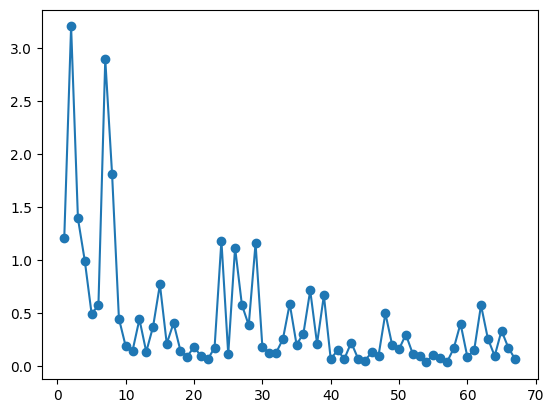

In [32]:

plt.plot(steps, train_loss, marker = 'o', linestyle='-')

### Task 5 - Deploy our model

Let's take a look at `retrieved_job` again

In [33]:
myLLM = retrieved_job.fine_tuned_model
print(myLLM)

ft:gpt-3.5-turbo-0125:personal::DYdEEz3x


Defining a method to extract information from a given user complaint using a specific LLM and return the results.

In [34]:
def extract_details(user_complaint, model_name):
    """
    This function extracts information from a given user complaint using a specific LLM (Large Language Model).

    Parameters:
    user_complaint (str): The text of the user's complaint.
    model_name (str): The name of the specific LLM model to use for extraction.
    """

    system_content = """
        Given a customer complaint text, extract and return the following information in JSON (dict) format:
        - Topic
        - Problem
        - Customer_Dissatisfaction_Index
    """

    # Generate a response using the specified model and the user's complaint
    response = client.chat.completions.create(
        model = model_name,
        messages=[
            {"role": "system", "content": system_content},  # System content explaining the expected output
            {"role": "user", "content": user_complaint}  # User's complaint passed as content
        ]
    )

    # Return the content of the generated response
    return response.choices[0].message.content


Let's use our fine-tuned model to extract the details for the following user complaint:

*TV channels keep disappearing from my subscription! What's going on? Extremely annoyed with this service!*

In [35]:
complaint = "TV channels keep disappearing from my subscription! what's going on? Extremely annoyed with this service!"
extract_details(complaint, myLLM)

'{"Topic": "TV", "Problem": "Channels disappearing from subscription", "Customer_Dissatisfaction_Index": "High"}'

Let's test our `GPT-4` model with the same user complaint

In [37]:
complaint = "TV channels keep disappearing from my subscription! what's going on? Extremely annoyed with this service!"
extract_details(complaint, 'gpt-4')

'{\n  "Topic": "TV Subscription",\n  "Problem": "TV channels are disappearing from the subscription",\n  "Customer_Dissatisfaction_Index": "High"\n}'

Let's try for the following complaint:

*Line is down! It is really annoying!*

In [38]:
complaint = "Line is down! It is really annoying!"
extract_details(complaint, myLLM)

'{"Topic": "Internet", "Problem": "Line is down", "Customer_Dissatisfaction_Index": 10}'

Now let's compare the results from GPT-4

In [40]:
complaint = "Line is down! It is really annoying!"
extract_details(complaint, 'gpt-4')

'{\n  "Topic": "Service issue",\n  "Problem": "Line is down",\n  "Customer_Dissatisfaction_Index": "High"\n}'

We can see that our model, which is trained on our dataset, provides better answers compared to GPT-4. Our model is fine-tuned based on our data and is familiar with the different edge cases and the context of our dataset.

In [41]:
customer_complaint = "I am very Angry! I want my money back!"
extract_details(complaint, myLLM)

'{"Topic": "Internet", "Problem": "Line down", "Customer_Dissatisfaction_Index": 10}'